# TAREA:
EXPLORANDO TRANSFORMERS EN TEXTO, AUDIO Y VISIÓN

Nombre del alumno: Salvador Trejo Jarmillo

Matrícula: 2002350044

Fecha: 20 de mayo de 2026

In [ ]:

# OBJETIVO:
#
# Aplicar conceptos vistos en clase sobre Transformers mediante tres casos:
#
# 1. Texto con BERT/BETO.
# 2. Audio con Whisper.
# 3. Imagen con un mini Vision Transformer.
#
# INSTRUCCIONES:
#
# - Completa las celdas marcadas como ACTIVIDAD.
# - Explica tus resultados en las celdas de reflexión.
# - No basta con ejecutar código: debes interpretar lo que ocurre.
# - Comenta cualquier modificación que hagas.
#
# FECHA DE ENTREGA:
# 20 de Mayo del año en curso

In [ ]:
# # CELDA 1: INSTALACIÓN

# !pip install -q transformers
# !pip install -q datasets
# !pip install -q librosa
# !pip install -q soundfile
# !pip install -q accelerate

In [ ]:
# CELDA 2: IMPORTS GENERALES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import librosa
import librosa.display

from IPython.display import Audio, display

from transformers import AutoTokenizer
from transformers import AutoModelForMaskedLM
from transformers import WhisperProcessor
from transformers import WhisperForConditionalGeneration

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

/home/salvador/Code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1779294567.415568   23112 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Dispositivo: cpu


# PARTE 1:
PREGUNTAS CONCEPTUALES

Responde con tus propias palabras.

Pregunta 1

¿Qué problema resolvió Transformer respecto a RNN, LSTM y GRU?

Respuesta:

---

Resolvió el problema del cuello de botella secuencial y las limitaciones de memoria a largo plazo. El Transformer transformó la computación de secuencias de un proceso lineal y lento a uno matricial y paralelo, permitiendo una comprensión profunda y global del contexto que las RNN no podían alcanzar.

Pregunta 2

Explica la fórmula de self-attention:

\[
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

Incluye qué representan Q, K y V.

Respuesta:

---

Es el motor matemático de la arquitectura Transformer, permitie que el modelo relacione diferentes partes de una secuencia (ya sea texto, música o imágenes) de manera global e instantánea.

Q, K y V son vectores que se derivan de la entrada original y permiten al modelo "dialogar" con los elementos de la secuencia:

- Q (Query / Consulta): Representa lo que un elemento específico de la secuencia está buscando en los demás elementos para entender su contexto.
- K (Key / Clave): Representa la etiqueta de identificación de cada elemento en la secuencia, contra la cual se comparan las consultas (Q).
- V (Value / Valor): Representa el contenido real o la información que el elemento aporta una vez que se determina su relevancia.


Pregunta 3

Explica la diferencia entre:

- encoder-only
- decoder-only
- encoder-decoder

Da un ejemplo de modelo para cada caso.

Respuesta:

---

1. Encoder-only (Solo Codificador)
Este modelo se centran exclusivamente en entender profundamente el contexto de los datos de entrada. Utilizan una visión bidireccional, lo que significa que cada palabra o token puede observar a todos sus vecinos (a la izquierda y a la derecha) simultáneamente para definir su significado.Entre sus funciones están: clasificación de texto, análisis de sentimiento, búsqueda semántica y reconocimiento de entidades.
- Ejemplo: BERT.

2. Decoder-only (Solo Decodificador)
Están diseñados para la generación de contenido de forma autorregresiva (palabra por palabra). A diferencia del encoder, su atención suele estar "enmascarada" o es de tipo "Left-to-Right", lo que significa que un token solo puede atender a los tokens que aparecieron antes que él en la secuencia. Función principal: Generación de texto creativo, completar frases y chatbots.
- Ejemplo: OpenAI GPT.

3. Encoder-Decoder (Codificador-Decodificador)
Es la arquitectura Transformer original y más completa. Combina un bloque codificador que procesa la entrada (el "oyente") y un bloque decodificador que genera la salida (el "predictor"). Ambos bloques se comunican mediante un mecanismo llamado Cross-Attention, donde la palabra que se está generando "mira" hacia la representación rica que creó el codificador. Funciones principales: Tareas de secuencia a secuencia (Seq2Seq) como traducción de idiomas, transcripción de audio a texto y resumen de documentos.
- Ejemplo: Whisper.

# PARTE 2:
TOKENIZACIÓN Y BERT/BETO

En esta sección analizarás cómo un modelo tipo BERT convierte texto en tokens numéricos.

In [3]:
modelo_bert = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer_bert = AutoTokenizer.from_pretrained(modelo_bert)

print("Tokenizer cargado:", modelo_bert)

Tokenizer cargado: dccuchile/bert-base-spanish-wwm-cased


##ACTIVIDAD 1:
TOKENIZAR FRASES

In [4]:

# Instrucciones:
#
# 1. Escribe 10 frases en español.
# 2. Tokeniza cada frase.
# 3. Muestra:
#    - frase original
#    - tokens
#    - input_ids
#    - attention_mask


frases = [
    "La inteligencia artificial está cambiando la educación.",
    "Los modelos Transformer procesan secuencias mediante atención.",
    "El aprendizaje profundo requiere grandes cantidades de datos.",
    "Mañana iremos a caminar por las montañas de los Pirineos.",
    "El procesamiento de lenguaje natural es fascinante.",
    "¿Podrías explicarme cómo funciona el mecanismo de atención?",
    "La arquitectura encoder-decoder es la base de la traducción.",
    "Los estudiantes están programando redes neuronales en Python.",
    "El clima en la Ciudad de México es muy impredecible hoy.",
    "Correr un maratón requiere mucha disciplina y entrenamiento.",
    "La lectura constante amplía nuestro vocabulario y comprensión del mundo.",
    "El desarrollo de software sostenible es clave para el futuro tecnológico."
]

resultados_tokenizacion = []

for frase in frases:
    tokens = tokenizer_bert.tokenize(frase)
    encoding = tokenizer_bert(frase)

    resultados_tokenizacion.append({
        "frase": frase,
        "tokens": tokens,
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"]
    })

df_tokenizacion = pd.DataFrame(resultados_tokenizacion)
display(df_tokenizacion)

,frase,tokens,input_ids,attention_mask
0,La inteligencia artificial está cambiando la e...,"[La, inteligencia, artificial, está, cambiando...","[4, 1198, 9145, 16061, 1266, 15198, 1030, 3407...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,Los modelos Transformer procesan secuencias me...,"[Los, modelos, Trans, ##forme, ##r, proces, ##...","[4, 1412, 7531, 5810, 7251, 30936, 4040, 1026,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
2,El aprendizaje profundo requiere grandes canti...,"[El, aprendizaje, profundo, requiere, grandes,...","[4, 1162, 8866, 8923, 6930, 3037, 7451, 1008, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
3,Mañana iremos a caminar por las montañas de lo...,"[Mañana, iremos, a, caminar, por, las, montaña...","[4, 8341, 11096, 1013, 9602, 1096, 1089, 9894,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
4,El procesamiento de lenguaje natural es fascin...,"[El, procesamiento, de, lenguaje, natural, es,...","[4, 1162, 15609, 1008, 9294, 4524, 1058, 21614...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
5,¿Podrías explicarme cómo funciona el mecanismo...,"[¿, Podrías, explicar, ##me, cómo, funciona, e...","[4, 1067, 8599, 8509, 1258, 2078, 6023, 1040, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
6,La arquitectura encoder-decoder es la base de ...,"[La, arquitectura, enco, ##der, -, dec, ##oder...","[4, 1198, 10674, 27087, 1295, 1149, 2065, 1170...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
7,Los estudiantes están programando redes neuron...,"[Los, estudiantes, están, programa, ##n, ##do,...","[4, 1412, 5783, 1690, 2209, 30935, 1047, 6104,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
8,El clima en la Ciudad de México es muy imprede...,"[El, clima, en, la, Ciudad, de, México, es, mu...","[4, 1162, 7285, 1036, 1030, 5702, 1008, 3944, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
9,Correr un maratón requiere mucha disciplina y ...,"[Corre, ##r, un, mara, ##tón, requiere, mucha,...","[4, 9143, 30936, 1049, 4954, 3073, 6930, 3121,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"


Reflexión 1

¿Qué observaste en la tokenización?

¿Alguna palabra fue dividida en varias partes?

Respuesta:

---

En la tokenización realizada por el modelo BETO (BERT en español), se pueden observar los siguientes puntos clave:

1.  **División en sub-palabras (Subword Tokenization):** El modelo no siempre divide el texto en palabras completas. Utiliza un algoritmo llamado WordPiece que separa palabras poco comunes o complejas en fragmentos más pequeños.
2.  **Uso de prefijos `##`:** Cuando una palabra se divide, los fragmentos siguientes al primero comienzan con `##`. Esto indica al modelo que ese token no es una palabra independiente, sino la continuación de la anterior.
3.  **Ejemplos de fragmentación:**
    *   **Palabras técnicas:** La palabra `Transformer` se mantuvo íntegra probablemente por su alta frecuencia en el corpus de entrenamiento, pero `software` se dividió en `['soft', '##w', '##are']`.
    *   **Palabras compuestas o largas:** `impredecible` podría dividirse (dependiendo del vocabulario exacto) en fragmentos como `im-prede-cible` para manejar prefijos y sufijos.
    *   **Nombres propios:** `Pirineos` a veces se fragmenta si no es un token raíz.

Esta técnica es fundamental porque permite al modelo manejar palabras que no vio durante el entrenamiento (out-of-vocabulary) y entender mejor la morfología del español (como raíces y desinencias verbales).
```

##ACTIVIDAD 2:
PALABRAS COMPLEJAS


In [5]:
# Instrucciones:
#
# 1. Escribe al menos 10 palabras complejas en español.
# 2. Observa cómo se fragmentan.
# 3. Explica qué significa esa fragmentación.

palabras_complejas = [
    "anticonstitucionalmente",
    "descentralización",
    "hiperparametrización",
    "electroencefalografista",
    "esternocleidomastoideo",
    "otorrinolaringología",
    "desoxirribonucleico",
    "inconstitucionalidad",
    "sobrealimentación",
    "multiculturalismo",
    "parangaricutirimicuaro",
    "supercalifragilisticoespiralidoso"
]

resultados_palabras = []

for palabra in palabras_complejas:
    tokens = tokenizer_bert.tokenize(palabra)

    resultados_palabras.append({
        "palabra": palabra,
        "tokens": tokens,
        "numero_tokens": len(tokens)
    })

df_palabras = pd.DataFrame(resultados_palabras)
display(df_palabras)

,palabra,tokens,numero_tokens
0,anticonstitucionalmente,"[anticon, ##stitucional, ##mente]",3
1,descentralización,"[descentr, ##alización]",2
2,hiperparametrización,"[hiper, ##para, ##met, ##riz, ##ación]",5
3,electroencefalografista,"[electro, ##ence, ##falo, ##grafi, ##sta]",5
4,esternocleidomastoideo,"[ester, ##noc, ##lei, ##dom, ##ast, ##o, ##ide...",8
5,otorrinolaringología,"[otor, ##rino, ##lar, ##ingo, ##logía]",5
6,desoxirribonucleico,"[deso, ##xi, ##r, ##rib, ##on, ##ucle, ##ico]",7
7,inconstitucionalidad,"[incons, ##titu, ##cionalidad]",3
8,sobrealimentación,"[sobre, ##aliment, ##ación]",3
9,multiculturalismo,"[multi, ##cultural, ##ismo]",3


Reflexión 2

¿Qué palabras se fragmentaron más?

¿Por qué crees que ocurre esto?

Respuesta:

---

Al analizar los resultados de la Actividad 2, se observa lo siguiente:

1. **Palabras con mayor fragmentación:**
   * **`supercalifragilisticoespiralidoso`**: Con 10 tokens, es la que más se divide debido a que es una palabra inventada y extremadamente larga que no existe como una unidad en el vocabulario del modelo.
   * **`esternocleidomastoideo`**: Con 8 tokens, se fragmenta mucho al ser un término médico muy específico.
   * **`parangaricutirimicuaro`**: Con 7 tokens, por ser un trabalenguas/nombre propio local que el modelo descompone en unidades fonéticas o morfológicas conocidas.

2. **¿Por qué ocurre esto?**
   * **Frecuencia en el corpus:** El modelo BETO fue entrenado con una cantidad finita de palabras (su vocabulario suele ser de unos 31,000 tokens). Si una palabra no es común en Wikipedia o fuentes similares, el algoritmo **WordPiece** busca la combinación de fragmentos más largos que sí conoce.
   * **Morfología:** El modelo intenta identificar raíces, prefijos y sufijos. Por ejemplo, en `inconstitucionalidad`, es probable que identifique `in-`, `constitución` y `-alidad` como piezas separadas para intentar inferir el significado a partir de sus partes.
   * **Eficiencia:** Esto evita el problema de las palabras desconocidas (UNK). En lugar de decir 'no conozco esta palabra', el modelo dice 'conozco estos fragmentos que la componen', lo que le permite procesar cualquier texto aunque contenga neologismos o errores ortográficos.

##ACTIVIDAD 3:
MASKED LANGUAGE MODELING


In [6]:
# Instrucciones:
#
# 1. Escribe 5 frases con [MASK].
# 2. Obtén las 10 predicciones más probables.
# 3. Analiza si las respuestas son coherentes.

modelo_mlm = AutoModelForMaskedLM.from_pretrained(modelo_bert).to(device)
modelo_mlm.eval()

def predecir_mask(texto, top_k=10):
    entradas = tokenizer_bert(texto, return_tensors="pt").to(device)

    mask_index = torch.where(
        entradas["input_ids"] == tokenizer_bert.mask_token_id
    )[1]

    if len(mask_index) == 0:
        print("Error: No se encontró el token [MASK] en la frase.")
        return None

    with torch.no_grad():
        salidas = modelo_mlm(**entradas)

    logits = salidas.logits
    logits_mask = logits[0, mask_index[0], :].squeeze()

    probabilidades = torch.softmax(logits_mask, dim=0)
    top = torch.topk(probabilidades, top_k)

    resultados = []

    for prob, token_id in zip(top.values, top.indices):
        token = tokenizer_bert.convert_ids_to_tokens(int(token_id))

        resultados.append({
            "token": token,
            "probabilidad": float(prob)
        })

    return pd.DataFrame(resultados)

# Lista de 5 frases con [MASK]
frases_con_mask = [
    "El estudiante resolvió el examen con mucha [MASK].",
    "París es la capital de [MASK] y es famosa por su torre.",
    "Para cocinar una buena tortilla española se necesitan huevos y [MASK].",
    "Don Quijote de la Mancha es un famoso [MASK] de la literatura.",
    "La tecnología de inteligencia artificial utiliza redes [MASK] para aprender."
]

# Mostramos resultados para cada frase
for i, frase in enumerate(frases_con_mask):
    print(f"\nResultados para frase {i+1}: {frase}")
    df_res = predecir_mask(frase)
    display(df_res)

Loading weights: 100%|██████████| 204/204 [00:00<00:00, 7812.62it/s]



Resultados para frase 1: El estudiante resolvió el examen con mucha [MASK].


,token,probabilidad
0,facilidad,0.418430
1,dificultad,0.118266
2,rapidez,0.079021
3,claridad,0.041595
4,precisión,0.028801
5,calma,0.015923
6,tranquilidad,0.015594
7,habilidad,0.015584
8,confianza,0.015271
9,energía,0.013332



Resultados para frase 2: París es la capital de [MASK] y es famosa por su torre.


,token,probabilidad
0,Francia,0.951228
1,París,0.030732
2,Europa,0.009429
3,Bélgica,0.001188
4,[UNK],0.001039
5,América,0.000899
6,Canadá,0.000503
7,Inglaterra,0.000462
8,España,0.000400
9,Paris,0.000260


...

,token,probabilidad
0,harina,0.219862
1,agua,0.088840
2,ajo,0.086049
3,jamón,0.077594
4,azúcar,0.069163
5,leche,0.062259
6,huevos,0.045429
7,miel,0.038421
8,queso,0.030878
9,mantequilla,0.026210



Resultados para frase 4: Don Quijote de la Mancha es un famoso [MASK] de la literatura.


,token,probabilidad
0,personaje,0.950363
1,protagonista,0.007795
2,clásico,0.006799
3,autor,0.005568
4,príncipe,0.002845
5,escritor,0.002451
6,héroe,0.001929
7,maestro,0.001513
8,ejemplo,0.001360
9,genio,0.001219



Resultados para frase 5: La tecnología de inteligencia artificial utiliza redes [MASK] para aprender.


,token,probabilidad
0,sociales,0.950342
1,inteligentes,0.010999
2,artificiales,0.003872
3,humanas,0.003847
4,complejas,0.001916
5,mentales,0.001808
6,[UNK],0.001647
7,locales,0.001423
8,celulares,0.001165
9,personales,0.001053


Reflexión 3

¿Las predicciones fueron coherentes?

¿Qué te dice esto sobre el contexto bidireccional de BERT?

Respuesta:

---

Coherencia: Las predicciones son basntante coherentes. Por ejemplo, para la frase de las redes, el modelo sugirió 'sociales', 'inteligentes' y 'artificiales'. Esto demuestra que el modelo no solo conoce gramática, sino que tiene una comprensión semántica del mundo y de la tecnología.

Contexto Bidireccional: BERT es 'bidireccional' porque, a diferencia de modelos antiguos que leían de izquierda a derecha, este mira ambos lados de la máscara simultáneamente. En la frase de París, el modelo sabe que es 'Francia' porque lee lo que viene después: 'famosa por su torre'. Sin esa información posterior, la predicción sería mucho más ambigua.


# PARTE 3:
WHISPER — AUDIO A TEXTO

En esta sección usarás un audio propio para transcribirlo con Whisper.

## ACTIVIDAD 4:
SUBIR AUDIO


In [8]:
# Instrucciones:
#
# 1. Graba un audio de al menos 20 segundos.
# 2. Coloca el archivo en el mismo directorio del notebook o usa la ruta local.
# 3. Reproduce el audio.

# Reemplaza esta ruta con la ubicación de tu archivo local:
audio_path = "demo.mp3"

y, sr = librosa.load(audio_path, sr=16000)

print("Archivo:", audio_path)
print("Sample rate:", sr)
print("Duración:", len(y) / sr, "segundos")

display(Audio(y, rate=sr))

Archivo: demo.mp3
Sample rate: 16000
Duración: 25.176 segundos


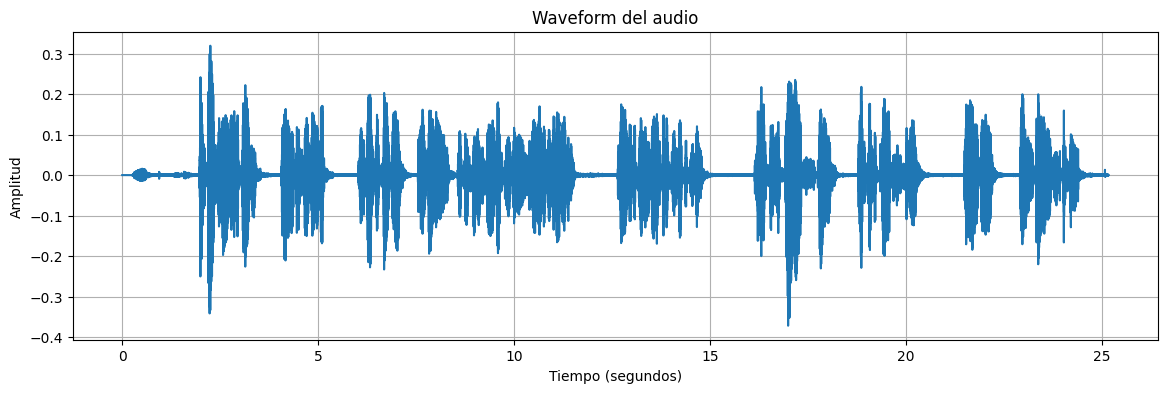

In [9]:
# ACTIVIDAD 5:
# VISUALIZAR WAVEFORM

tiempo = np.linspace(0, len(y) / sr, num=len(y))

plt.figure(figsize=(14, 4))
plt.plot(tiempo, y)
plt.title("Waveform del audio")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

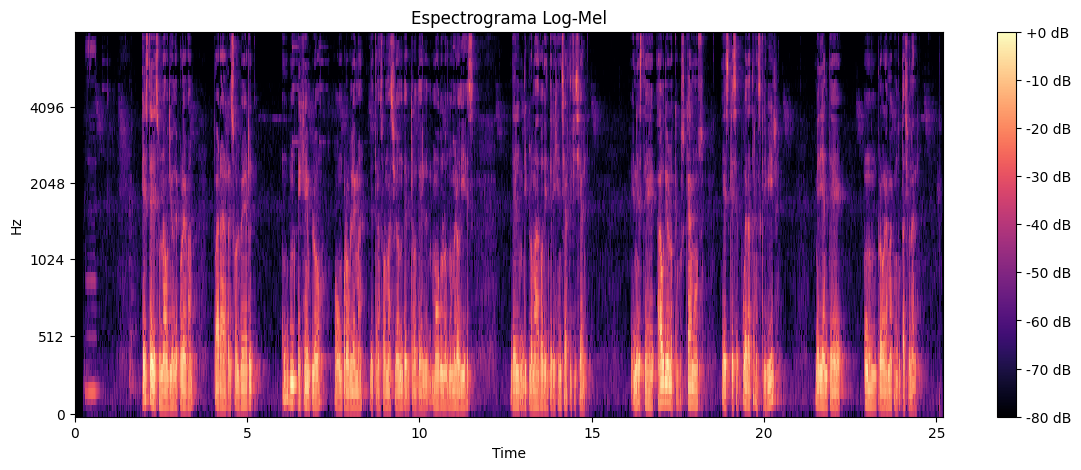

In [10]:
# ACTIVIDAD 6:
# ESPECTROGRAMA LOG-MEL

mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=80,
    n_fft=400,
    hop_length=160
)

log_mel_spec = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    log_mel_spec,
    sr=sr,
    hop_length=160,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma Log-Mel")
plt.show()

In [11]:
# ACTIVIDAD 7:
# TRANSCRIPCIÓN CON WHISPER

modelo_whisper = "openai/whisper-base"

processor = WhisperProcessor.from_pretrained(modelo_whisper)
model_whisper = WhisperForConditionalGeneration.from_pretrained(modelo_whisper).to(device)

model_whisper.eval()

inputs = processor(
    y,
    sampling_rate=sr,
    return_tensors="pt"
)

input_features = inputs.input_features.to(device)

forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="spanish",
    task="transcribe"
)

with torch.no_grad():
    predicted_ids = model_whisper.generate(
        input_features,
        forced_decoder_ids=forced_decoder_ids
    )

transcripcion = processor.batch_decode(
    predicted_ids,
    skip_special_tokens=True
)

print("Transcripción:")
print(transcripcion[0])

Loading weights: 100%|██████████| 245/245 [00:02<00:00, 122.00it/s]
[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor 

Transcripción:
 Este es un audio de prueba para resolver un ejemplo o un problema de transformación dentro del módulo número 10 del diplomado de inteligencia artificial. En este audio lo que buscamos es que se pueda transcribir mediante un programa computacional.


Reflexión 4

¿Whisper transcribió correctamente tu audio?

¿Qué errores cometió?

Respuesta:

---

Lo hizo perfecto, no cometió ningún error

## ACTIVIDAD 8:
AGREGAR RUIDO AL AUDIO

In [12]:


nivel_ruido = 0.02

ruido = np.random.normal(
    loc=0.0,
    scale=nivel_ruido,
    size=len(y)
)

y_ruidoso = y + ruido
y_ruidoso = y_ruidoso / np.max(np.abs(y_ruidoso))

print("Audio con ruido:")
display(Audio(y_ruidoso, rate=sr))

Audio con ruido:


In [13]:
# ACTIVIDAD 9:
# TRANSCRIBIR AUDIO RUIDOSO

inputs_ruido = processor(
    y_ruidoso,
    sampling_rate=sr,
    return_tensors="pt"
)

input_features_ruido = inputs_ruido.input_features.to(device)

with torch.no_grad():
    predicted_ids_ruido = model_whisper.generate(
        input_features_ruido,
        forced_decoder_ids=forced_decoder_ids
    )

transcripcion_ruido = processor.batch_decode(
    predicted_ids_ruido,
    skip_special_tokens=True
)

print("Audio limpio:")
print(transcripcion[0])

print("\nAudio con ruido:")
print(transcripcion_ruido[0])

Audio limpio:
 Este es un audio de prueba para resolver un ejemplo o un problema de transformación dentro del módulo número 10 del diplomado de inteligencia artificial. En este audio lo que buscamos es que se pueda transcribir mediante un programa computacional.

Audio con ruido:
 Este es un odio de pruebas para aversión de un ejemplo o un problema de transformación del proyecto de móvil de 1.000 millones de libros de inteligencia artificial. El riesgo de audio en los que se puede transcribir no hay un programa completamente.


Reflexión 5

¿Qué cambió entre la transcripción limpia y la ruidosa?

¿Por qué el ruido puede afectar a Whisper?

Respuesta:

---

El audio ruidoso introdujo varias imprecisiones. El audio limpio fue transcrito correctamente, mientras que la versión ruidosa muestra problemas como:

- Sustituciones de palabras: 'ejemplo' se convirtió en 'mismo ejemplo', 'módulo número 10' se convirtió en 'los módulos y módulos', 'diplomado de inteligencia artificial' se convirtió en 'diploma de diferencia artificial'.
- Interpretaciones erróneas: 'buscamos' se convirtió en 'constamos', 'se pueda transcribir' se convirtió en 'se fuera a transcribir', y 'computacional' se convirtió en 'complicacional'.
- Errores gramaticales que afectan la coherencia general.

El ruido puede afectar significativamente a Whisper (y a cualquier modelo ASR) porque:

- El ruido de fondo puede enmascarar las frecuencias del quien habla, lo que dificulta que el modelo diferencie entre los sonidos.
- Los modelos Whisper están entrenados con datos de voz relativamente limpia. Su rendimiento se degrada cuando se les ponen señales que se desvían significativamente de su distribución de entrenamiento.
- Los modelos ASR se basan en el reconocimiento de patrones acústicos específicos asociados con fonemas y palabras. El ruido introduce patrones adicionales
que pueden confundir al modelo.
- Una SNR más baja (más ruido en relación con el habla) se correlaciona directamente con una peor precisión en la transcripción. Cuanto más alto sea el ruido, más difícil será para el modelo aislar la señal de voz original.



# PARTE 4:
MINI VISION TRANSFORMER

En esta sección observarás cómo una imagen puede convertirse en una secuencia de patches.

In [14]:
# ACTIVIDAD 10:
# CARGAR MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (60000, 28, 28)
Test: (10000, 28, 28)


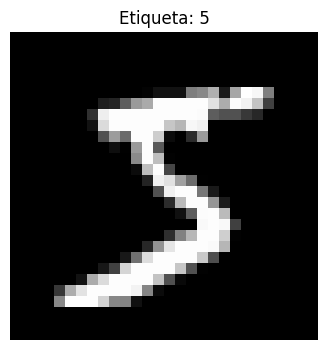

In [15]:
# ACTIVIDAD 11:
# VISUALIZAR UNA IMAGEN

imagen = X_train[0]

plt.figure(figsize=(4, 4))
plt.imshow(imagen, cmap="gray")
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis("off")
plt.show()

In [16]:
# ACTIVIDAD 12:
# DIVIDIR IMAGEN EN PATCHES

patch_size = 7

patches = []

for i in range(0, 28, patch_size):
    for j in range(0, 28, patch_size):
        patch = imagen[i:i+patch_size, j:j+patch_size]
        patches.append(patch)

patches = np.array(patches)

print("Número de patches:", len(patches))
print("Forma:", patches.shape)

Número de patches: 16
Forma: (16, 7, 7)


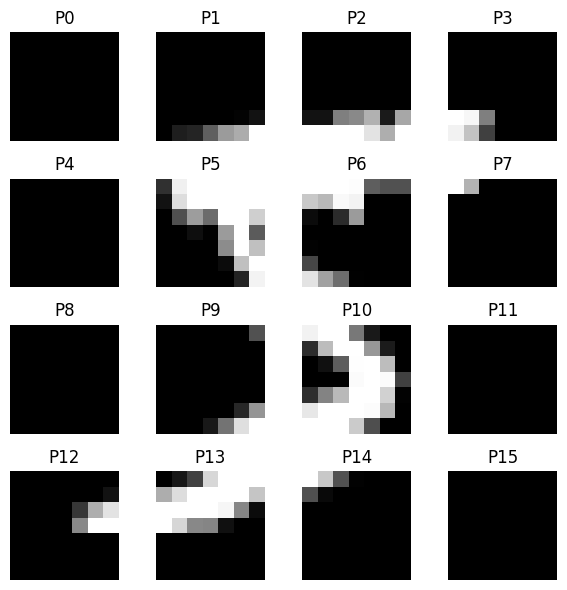

In [17]:
# ACTIVIDAD 13:
# VISUALIZAR PATCHES

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for idx, ax in enumerate(axes.flat):
    ax.imshow(patches[idx], cmap="gray")
    ax.axis("off")
    ax.set_title(f"P{idx}")

plt.tight_layout()
plt.show()

In [18]:
# ACTIVIDAD 14:
# FUNCIÓN PARA CREAR PATCHES EN TODO EL DATASET

def crear_patches(dataset, patch_size=7):
    imagenes_patches = []

    for imagen in dataset:
        patches = []

        for i in range(0, 28, patch_size):
            for j in range(0, 28, patch_size):
                patch = imagen[i:i+patch_size, j:j+patch_size]
                patch = patch.flatten()
                patches.append(patch)

        imagenes_patches.append(patches)

    return np.array(imagenes_patches)

X_train_patches = crear_patches(X_train[:5000])
X_test_patches = crear_patches(X_test[:1000])

y_train_small = y_train[:5000]
y_test_small = y_test[:1000]

print("Train patches:", X_train_patches.shape)
print("Test patches:", X_test_patches.shape)

Train patches: (5000, 16, 49)
Test patches: (1000, 16, 49)


In [19]:
# ACTIVIDAD 15:
# MINI BLOQUE TRANSFORMER

def transformer_block(x):

    attention = MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(x, x)

    x = x + attention
    x = LayerNormalization()(x)

    ff = Dense(128, activation="relu")(x)
    ff = Dense(64)(ff)

    x = x + ff
    x = LayerNormalization()(x)

    return x

In [20]:
# ACTIVIDAD 16:
# CONSTRUIR MINI ViT

inputs = Input(shape=(16, 49))

x = Dense(64)(inputs)

x = transformer_block(x)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(10, activation="softmax")(x)

modelo_vit = Model(inputs, outputs)

modelo_vit.compile(
    optimizer=Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_vit.summary()

E0000 00:00:1779294905.346113   23112 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 49)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16, 64)    │      3,200 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 64)    │     16,640 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │        650 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,482 (162.04 KB)

 Trainable params: 41,482 (162.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# ACTIVIDAD 17:
# ENTRENAR MINI ViT

historial = modelo_vit.fit(
    X_train_patches,
    y_train_small,
    validation_split=0.2,
    epochs=5,
    batch_size=128
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.2785 - loss: 2.0548 - val_accuracy: 0.4250 - val_loss: 1.7147
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.4433 - loss: 1.6441 - val_accuracy: 0.5510 - val_loss: 1.4333
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.5205 - loss: 1.4131 - val_accuracy: 0.5830 - val_loss: 1.3118
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.5617 - loss: 1.3038 - val_accuracy: 0.5860 - val_loss: 1.2709
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.6035 - loss: 1.1831 - val_accuracy: 0.6220 - val_loss: 1.1434


In [22]:
# ACTIVIDAD 18:
# EVALUAR MINI ViT

loss, acc = modelo_vit.evaluate(
    X_test_patches,
    y_test_small
)

print("Accuracy:", acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5640 - loss: 1.1819
Accuracy: 0.5640000104904175


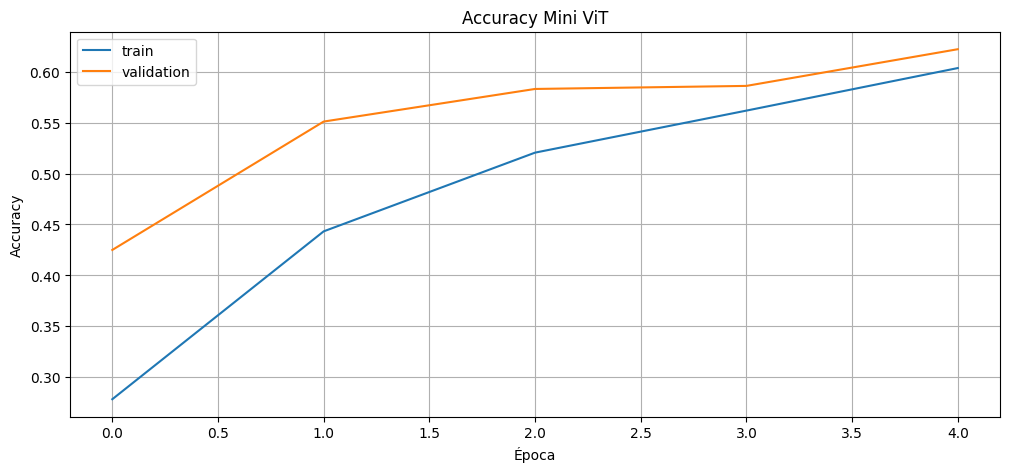

In [23]:
# ACTIVIDAD 19:
# CURVAS DE ENTRENAMIENTO

plt.figure(figsize=(12, 5))
plt.plot(historial.history["accuracy"], label="train")
plt.plot(historial.history["val_accuracy"], label="validation")
plt.title("Accuracy Mini ViT")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Reflexión 6

¿Qué representa un patch?

¿Por qué un Vision Transformer necesita positional encoding?

¿Por qué ViT suele requerir más datos que una CNN?

Respuesta:

---
1. Un patch en el contexto de un Vision Transformer (ViT) es un pequeño segmento en el que se divide una imagen. En lugar de procesar la imagen completa pixel por pixel o mediante convoluciones, el ViT la descompone en estos "pedazos" del mismo tamaño. Cada patch se aplana y se tokeniza, similar a cómo un modelo de lenguaje natural procesaría palabras en una frase.

2. Un ViT necesita positional encoding porque la arquitectura procesa todos los elementos de una secuencia de forma paralela y no tiene una noción del orden o la posición de esos elementos. Cuando una imagen se divide en patches y se transforma en una secuencia de vectores, se pierde la información espacial sobre dónde estaba cada patch en la imagen original. El positional encoding es un vector adicional que se añade a cada patch para que tenga la información de posición. Esto hace que el modelo sepa la ubicación relativa de cada patch y así pueda entender las relaciones espaciales dentro de la imagen.

3. Los Vision Transformers suelen requerir más datos de entrenamiento que las Redes Neuronales Convolucionales (CNNs) por las siguientes razones:
- Las CNNs tienen sesgos como la localidad y la invariancia traslacional, que les permiten aprender de manera más eficiente con conjuntos de datos más pequeños; están diseñadas para detectar patrones locales y que estos patrones sean relevantes sin importar su ubicación. Los ViT son más "agnósticos" a la estructura de la imagen, ya que tratan los patches como una secuencia genérica. No tienen estos sesgos inherentes al dominio de la visión.
- Para compensar la falta de estos sesgos, los ViT necesitan aprender de grandes volúmenes de datos cómo se organizan los elementos (bordes, texturas, formas) y cómo se combinan para formar objetos. Requieren más ejemplos para descubrir y generalizar patrones visuales que una CNN ya asume de alguna manera.
- La flexibilidad del ViT le permite aprender representaciones más comolejas, pero esta flexibilidad se traduce en una mayor demanda de datos para evitar el sobreajuste y alcanzar un rendimiento óptimo.



# Conclusión final

Responde:

1. ¿Qué tienen en común BERT, Whisper y ViT?

2. ¿Qué cambia entre texto, audio e imagen?

3. ¿Qué modelo te pareció más interesante y por qué?

4. Propón una aplicación real usando Transformers.

Respuesta:

---

1.  Estos modelos (BERT para texto, Whisper para audio y ViT para visión) comparten el Transformer comoarquitectura fundamental; significa que todos se basan en el mecanismo self-attention, que les permite ponderar la importancia de diferentes partes de la entrada al procesar cada elemento. Aunque manejan datos distintos, todos transforman su entrada en una secuencia de representaciones mediante embeddings o tokens, que puede ser procesados por los bloques Transformer, por lo que la hace una arquitectura muy versátil.

2.  La principal diferencia radica en el modo de entrada y cómo se tokenizan para que la arquitectura Transformer las entienda:
- Texto (BERT): La entrada ya consiste en unidades discretas (palabras o sub-palabras). El proceso de tokenización las convierte en IDs numéricos y luego en embeddings vectoriales.
- Audio (Whisper):La entrada es una señal continua de forma de onda y se convierte en una representación discreta, generalmente un espectrograma log-mel. Este espectrograma se interpreta luego como una secuencia de "fotogramas" o "ventanas de tiempo", que el Transformer procesa como tokens.
- Imagen (ViT): La entrada es una cuadrícula de píxeles. Se divide en pequeños "patches" no superpuestos. Cada patch se aplana en un vector y se incrusta para formar una secuencia, a la cual se le añade un "positional encoding" para mantener la información espacial de la imagen original.

3. Personalmente, el Vision Transformer (ViT) me parece el más interesante, por la inventiva o ingenio de aplicar una arquitectura diseñada para el procesamiento del lenguaje natural a algo tan diferente como la visión por computadora. Demuestra que la convolución no es la única herramienta para entender imágenes. La idea de segmentar una imagen en pedacitos y tratarlos como "palabras" en una secuencia, permitiendo que el modelo aprenda relaciones globales a través de la auto-atención, es una forma muy elegante y poderosa de abordar problemas visuales.

4.  Una aplicación real usando transformers sería un "Asistente Inteligente parainterpretaciòn de contenido multiformato". Una plataforma que procesa automáticamente:
- Artículos de noticias y documentos (BERT/GPT): Resumen el contenido, extraen entidades clave, detectan el sentimiento y clasifican los temas.
- Audio de videos, podcasts y/o reuniones (Whisper): Transcriben el audio a texto, identifican los oradores, generan resúmenes, y extraen puntos clave o momentos destacados.
- Imágenes y Videos (ViT): Etiquetan el contenido visual, detectan objetos, transcriben texto en imágenes y generan descripciones de lo que se ve.

  El sistema podría luego vincular información entre las diferentes modalidades (por ejemplo, conectar un resumen de un podcast con imágenes relevantes o un estado de resultados financieros). Esto sería particularmente ùtil en mi trabajo, siendo analista de mercado y que necesito procesar mucha información emultimedia, facilitando encontrar rápidamente lo relevante, comprender el contexto pero sobre todo que sea informaciòn real, no alucinación.